# 🐟 Impact of Image Blur & Enhancement on YOLOv11n Underwater Fish Detection
**Dataset**: URPC2020 (YOLO format) | **Model**: YOLOv11n

**Pipeline**: Baseline → Blur Simulation → Multi-Enhancement → Comparison

**Enhancements**: CLAHE, Unsharp Masking, CLAHE + Unsharp (combined)

## Step 1: Install & Restart
Run this cell alone, then restart the kernel, then run from Step 2.

In [ ]:
import subprocess, sys
result = subprocess.run(
    [sys.executable, '-m', 'pip', 'install', 'ultralytics', '-q', '--upgrade'],
    capture_output=True, text=True
)
print(result.stdout[-500:] if result.stdout else '')
print('✅ Done. Now restart kernel and run from Step 2 onwards.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 45.9 MB/s eta 0:00:00

✅ Done. Now restart kernel and run from Step 2 onwards.


## Step 2: Imports & Paths

In [ ]:
import os, shutil, random, time, yaml, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from ultralytics import YOLO

# ── Paths ─────────────────────────────────────────────────────────────────────
URPC_ROOT   = Path('/kaggle/input/datasets/rouchimahajan/urpc-enhancement/URPC2020')
BASE_DIR    = Path('/kaggle/working')
WORK_DIR    = BASE_DIR / 'yolo_data'
RESULTS_DIR = BASE_DIR / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
WORK_DIR.mkdir(parents=True, exist_ok=True)

# ── Read the dataset yaml shipped with URPC ───────────────────────────────────
src_yaml = URPC_ROOT / 'data.yaml'
with open(src_yaml) as f:
    orig_yaml = yaml.safe_load(f)

print('Original data.yaml:')
print(orig_yaml)
CLASS_NAMES = orig_yaml.get('names', [])
NC          = len(CLASS_NAMES)
print(f'\nClasses ({NC}): {CLASS_NAMES}')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Original data.yaml:
{'train': '/home/wly/pycharmProjects/underwater-biometrics/data/URPC2020/train/images', 'val': '/home/wly/pycharmProjects/underwater-biometrics/data/URPC2020/valid/images', 'test': '/home/wly/pycharmProjects/underwater-biometrics/data/URPC2020/test/images', 'nc': 4, 'names': ['holothurian', 'echinus', 'scallop', 'starfish'], 'roboflow': {'workspace': 'brad-dwyer', 'project': 'aquarium-combined', 'version': 6, 'license': 'CC BY 4.0', 'url': 'https://universe.roboflow.com/brad-dwyer/aquarium-combined/dataset/6'}}

Classes (4): ['holothurian', 'echinus', 'scallop', 'starfish']


## Step 3: Write Fixed dataset.yaml

In [ ]:
fixed_yaml = {
    'path' : str(URPC_ROOT),
    'train': 'train/images',
    'val'  : 'valid/images',
    'test' : 'test/images',
    'nc'   : NC,
    'names': CLASS_NAMES
}

YAML_PATH = WORK_DIR / 'dataset.yaml'
with open(YAML_PATH, 'w') as f:
    yaml.dump(fixed_yaml, f, default_flow_style=False)

print('dataset.yaml written:')
print(open(YAML_PATH).read())

# Verify image/label counts
for split in ['train', 'valid', 'test']:
    imgs = list((URPC_ROOT / split / 'images').iterdir())
    lbls = list((URPC_ROOT / split / 'labels').iterdir())
    print(f'{split}: {len(imgs)} images, {len(lbls)} labels')

dataset.yaml written:
names:
- holothurian
- echinus
- scallop
- starfish
nc: 4
path: /kaggle/input/datasets/rouchimahajan/urpc-enhancement/URPC2020
test: test/images
train: train/images
val: valid/images

train: 5543 images, 5543 labels
valid: 1200 images, 1200 labels
test: 800 images, 800 labels


## Step 4: Baseline Training — YOLOv11n

In [ ]:
EPOCHS   = 50
IMG_SIZE = 640
BATCH    = 32
PATIENCE = 10

MODEL_NAME = 'YOLOv11n'
WEIGHTS    = 'yolo11n.pt'

print(f'\n{"+"*60}\nTraining {MODEL_NAME}\n{"+"*60}')

model = YOLO(WEIGHTS)
model.train(
    data     = str(YAML_PATH),
    epochs   = EPOCHS,
    imgsz    = IMG_SIZE,
    batch    = BATCH,
    patience = PATIENCE,
    device   = 0,
    workers  = 4,
    cache    = True,
    project  = str(RESULTS_DIR / 'train'),
    name     = MODEL_NAME,
    exist_ok = True,
    verbose  = True
)

BEST_WTS = RESULTS_DIR / 'train' / MODEL_NAME / 'weights' / 'best.pt'
print(f'✅ Saved: {BEST_WTS}')


++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Training YOLOv11n
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_data/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mos

## Step 5: Helper Functions — Evaluation, Blur, Enhancement

In [ ]:
TEST_IMG_DIR = URPC_ROOT / 'test' / 'images'
TEST_LBL_DIR = URPC_ROOT / 'test' / 'labels'

# ── Evaluation helper ─────────────────────────────────────────────────────────
def get_metrics(weights, yaml_path, img_dir, split='test'):
    """Returns mAP50, Precision, Recall, F1, FPS."""
    model   = YOLO(str(weights))
    metrics = model.val(data=str(yaml_path), split=split,
                        imgsz=IMG_SIZE, batch=BATCH, verbose=False)
    sample = list(Path(img_dir).iterdir())[:50]
    t0  = time.time()
    model.predict(sample, imgsz=IMG_SIZE, verbose=False)
    fps = len(sample) / (time.time() - t0)
    p, r = metrics.box.mp, metrics.box.mr
    return {
        'mAP50'    : round(metrics.box.map50, 4),
        'Precision': round(p, 4),
        'Recall'   : round(r, 4),
        'F1'       : round(2*p*r/(p+r+1e-9), 4),
        'FPS'      : round(fps, 1)
    }

def make_temp_yaml(img_dir):
    """Write a temp yaml pointing test split to a custom image folder."""
    img_dir = Path(img_dir)
    # Symlink labels folder next to images folder so YOLO can resolve them
    lbl_link = img_dir.parent / 'labels'
    if not lbl_link.exists():
        try:
            lbl_link.symlink_to(TEST_LBL_DIR)
        except Exception:
            pass  # Already exists or permission issue
    tmp = {
        'path' : str(img_dir.parent.parent),
        'train': str(URPC_ROOT / 'train' / 'images'),
        'val'  : str(URPC_ROOT / 'valid' / 'images'),
        'test' : str(img_dir),
        'nc'   : NC,
        'names': CLASS_NAMES
    }
    yp = img_dir.parent / 'tmp.yaml'
    with open(yp, 'w') as f:
        yaml.dump(tmp, f)
    return yp

def eval_on_dir(weights, img_dir):
    """Evaluate model on images in img_dir, with labels from original test set."""
    yp    = make_temp_yaml(img_dir)
    model = YOLO(str(weights))
    met   = model.val(data=str(yp), split='test',
                      imgsz=IMG_SIZE, batch=BATCH, verbose=False)
    imgs  = list(Path(img_dir).iterdir())[:50]
    t0    = time.time()
    model.predict(imgs, imgsz=IMG_SIZE, verbose=False)
    fps   = len(imgs) / (time.time() - t0)
    p, r  = met.box.mp, met.box.mr
    return {
        'mAP50'    : round(met.box.map50, 4),
        'Precision': round(p, 4),
        'Recall'   : round(r, 4),
        'F1'       : round(2*p*r/(p+r+1e-9), 4),
        'FPS'      : round(fps, 1)
    }

def make_transformed_testset(tag, transform_fn, src_dir=None):
    """Apply transform_fn to all images in src_dir, save to WORK_DIR/test_{tag}/images."""
    if src_dir is None:
        src_dir = TEST_IMG_DIR
    out_dir = WORK_DIR / f'test_{tag}' / 'images'
    out_dir.mkdir(parents=True, exist_ok=True)
    for p in Path(src_dir).iterdir():
        if p.suffix.lower() not in ['.jpg', '.jpeg', '.png', '.bmp']:
            continue
        img = cv2.imread(str(p))
        if img is None:
            continue
        transformed = transform_fn(img)
        cv2.imwrite(str(out_dir / p.name), transformed)
    return out_dir

# ── Blur functions ────────────────────────────────────────────────────────────
def gaussian_blur(img, sigma):
    k = int(6 * sigma + 1) | 1  # ensure odd kernel
    return cv2.GaussianBlur(img, (k, k), sigma)

def motion_blur(img, k):
    kernel = np.zeros((k, k), dtype=np.float32)
    kernel[k // 2, :] = 1.0 / k
    return cv2.filter2D(img, -1, kernel)

# ── Enhancement functions ─────────────────────────────────────────────────────
def apply_clahe(img, clip_limit=3.0, tile_grid=(8, 8)):
    """CLAHE on L channel in LAB space — boosts local contrast."""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    cl = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid).apply(l)
    return cv2.cvtColor(cv2.merge((cl, a, b)), cv2.COLOR_LAB2BGR)

def apply_unsharp_mask(img, sigma=1.0, strength=1.5):
    """Unsharp masking — sharpens edges by amplifying high-frequency details."""
    blurred = cv2.GaussianBlur(img, (0, 0), sigma)
    sharpened = cv2.addWeighted(img, 1.0 + strength, blurred, -strength, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)

def apply_clahe_unsharp(img):
    """Combined: CLAHE first for contrast, then Unsharp Mask for sharpness."""
    return apply_unsharp_mask(apply_clahe(img, clip_limit=3.0), sigma=1.0, strength=1.5)

BLUR_CONFIGS = {
    'gaussian_s1' : lambda i: gaussian_blur(i, 1),
    'gaussian_s3' : lambda i: gaussian_blur(i, 3),
    'gaussian_s5' : lambda i: gaussian_blur(i, 5),
    'motion_k5'   : lambda i: motion_blur(i, 5),
    'motion_k10'  : lambda i: motion_blur(i, 10),
    'motion_k15'  : lambda i: motion_blur(i, 15),
}

ENHANCE_CONFIGS = {
    'clahe'         : apply_clahe,
    'unsharp'       : apply_unsharp_mask,
    'clahe_unsharp' : apply_clahe_unsharp,
}

print('✅ All helpers defined.')

✅ All helpers defined.


## Step 6: Baseline Evaluation on Clear Test Images

In [ ]:
print(f'Evaluating {MODEL_NAME} on clear test images...')
baseline_metrics = get_metrics(BEST_WTS, YAML_PATH, TEST_IMG_DIR)
print(f'Baseline: {baseline_metrics}')

CLEAR_MAP = baseline_metrics['mAP50']
print(f'\n✅ Baseline mAP50 = {CLEAR_MAP}')

Evaluating YOLOv11n on clear test images...
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 18.7±18.9 MB/s, size: 311.0 KB)
val: Scanning /kaggle/input/datasets/rouchimahajan/urpc-enhancement/URPC2020/test/labels... 800 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 115.0it/s 7.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/rouchimahajan/urpc-enhancement/URPC2020/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.2it/s 11.4s
                   all        800       6581      0.784      0.674      0.758      0.426
Speed: 1.3ms preprocess, 2.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
Baseline: {'mAP50': np.float64(0.7577), 'Precision': n

## Step 7: Blur Simulation & Evaluation

In [ ]:
blur_results = {'clear': baseline_metrics}
blur_dirs    = {}

for bname, bfn in BLUR_CONFIGS.items():
    print(f'  Creating & evaluating {bname}...')
    bdir = make_transformed_testset(bname, bfn, src_dir=TEST_IMG_DIR)
    blur_dirs[bname]    = bdir
    blur_results[bname] = eval_on_dir(BEST_WTS, bdir)
    print(f'    mAP50 = {blur_results[bname]["mAP50"]}')

df_blur = pd.DataFrame(blur_results).T
print('\n── Blur Results ──')
print(df_blur)

  Creating & evaluating gaussian_s1...
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4545.3±649.0 MB/s, size: 861.0 KB)
val: Scanning /kaggle/working/yolo_data/test_gaussian_s1/labels... 800 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 967.4it/s 0.8s
val: New cache created: /kaggle/working/yolo_data/test_gaussian_s1/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 1.9it/s 13.3s
                   all        800       6581      0.792      0.672      0.763       0.43
Speed: 1.4ms preprocess, 2.3ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to /kaggle/working/runs/detect/val2
    mAP50 = 0.7633
  Creating & evaluating gaussian_s3...
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 149

## Step 8: Enhancement Evaluation
Enhancements are tested on: (a) clear images, and (b) worst blurred images

In [ ]:
# Select 2 worst blurred conditions (lowest mAP50)
WORST_BLURS = sorted(
    [k for k in blur_results if k != 'clear'],
    key=lambda k: blur_results[k]['mAP50']
)[:2]
print(f'Worst blurs selected for enhancement: {WORST_BLURS}')

enh_results = {}

# ── Enhancement on clear images ───────────────────────────────────────────────
for ename, efn in ENHANCE_CONFIGS.items():
    tag = f'clear+{ename}'
    print(f'  {tag}...')
    edir = make_transformed_testset(tag, efn, src_dir=TEST_IMG_DIR)
    enh_results[tag] = eval_on_dir(BEST_WTS, edir)
    print(f'    mAP50 = {enh_results[tag]["mAP50"]}')

# ── Enhancement on blurred images ─────────────────────────────────────────────
for bname in WORST_BLURS:
    bdir = blur_dirs[bname]
    for ename, efn in ENHANCE_CONFIGS.items():
        tag = f'{bname}+{ename}'
        print(f'  {tag}...')
        edir = make_transformed_testset(tag, efn, src_dir=bdir)
        enh_results[tag] = eval_on_dir(BEST_WTS, edir)
        print(f'    mAP50 = {enh_results[tag]["mAP50"]}')

df_enh = pd.DataFrame(enh_results).T
print('\n── Enhancement Results ──')
print(df_enh)

Worst blurs selected for enhancement: ['gaussian_s5', 'motion_k15']
  clear+clahe...
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4790.9±857.7 MB/s, size: 1639.1 KB)
val: Scanning /kaggle/working/yolo_data/test_clear+clahe/labels... 800 images, 25 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 800/800 975.4it/s 0.8s
val: New cache created: /kaggle/working/yolo_data/test_clear+clahe/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 1.6it/s 15.5s
                   all        800       6581      0.741      0.538      0.615      0.324
Speed: 1.7ms preprocess, 2.3ms inference, 0.0ms loss, 1.4ms postprocess per image
Results saved to /kaggle/working/runs/detect/val8
    mAP50 = 0.6149
  clear+unsharp...
Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.10.0+

## Step 9: Full Comparison Table

In [ ]:
def pct(val, ref):
    return round((val - ref) / (ref + 1e-9) * 100, 2)

def recovery(row, blur_results, CLEAR_MAP):
    cond = row['Condition']
    if '+' not in cond:
        return np.nan
    blur_part = cond.split('+')[0]
    if blur_part == 'clear' or blur_part not in blur_results:
        return np.nan
    bm = blur_results[blur_part]['mAP50']
    drop = CLEAR_MAP - bm
    if abs(drop) < 1e-9:
        return np.nan
    return round((row['mAP50'] - bm) / drop * 100, 2)

all_res = {**blur_results, **enh_results}
df_all  = pd.DataFrame(all_res).T.reset_index().rename(columns={'index': 'Condition'})
df_all['vs_clear(%)'] = df_all['mAP50'].apply(lambda x: pct(x, CLEAR_MAP))
df_all['Recovery(%)'] = df_all.apply(lambda row: recovery(row, blur_results, CLEAR_MAP), axis=1)

df_all.to_csv(RESULTS_DIR / 'comparison.csv', index=False)

print('=' * 90)
print(df_all.to_string(index=False))
print('=' * 90)

                Condition  mAP50  Precision  Recall     F1  FPS  vs_clear(%)  Recovery(%)
                    clear 0.7577     0.7839  0.6742 0.7249  8.2         0.00          NaN
              gaussian_s1 0.7633     0.7923  0.6715 0.7269  9.0         0.74          NaN
              gaussian_s3 0.7308     0.7823  0.6400 0.7041  9.2        -3.55          NaN
              gaussian_s5 0.6726     0.7536  0.5967 0.6660  9.3       -11.23          NaN
                motion_k5 0.7614     0.7892  0.6723 0.7261  9.0         0.49          NaN
               motion_k10 0.7424     0.7577  0.6622 0.7068  8.7        -2.02          NaN
               motion_k15 0.7174     0.7676  0.6356 0.6954  9.0        -5.32          NaN
              clear+clahe 0.6149     0.7407  0.5383 0.6235  8.3       -18.85          NaN
            clear+unsharp 0.7281     0.7671  0.6447 0.7006  8.3        -3.91          NaN
      clear+clahe_unsharp 0.5568     0.7157  0.4821 0.5761  6.7       -26.51          NaN
        ga

## Step 10: Visualizations

/tmp/ipykernel_24/3725460520.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(blur_keys, rotation=30, ha='right', fontsize=9)


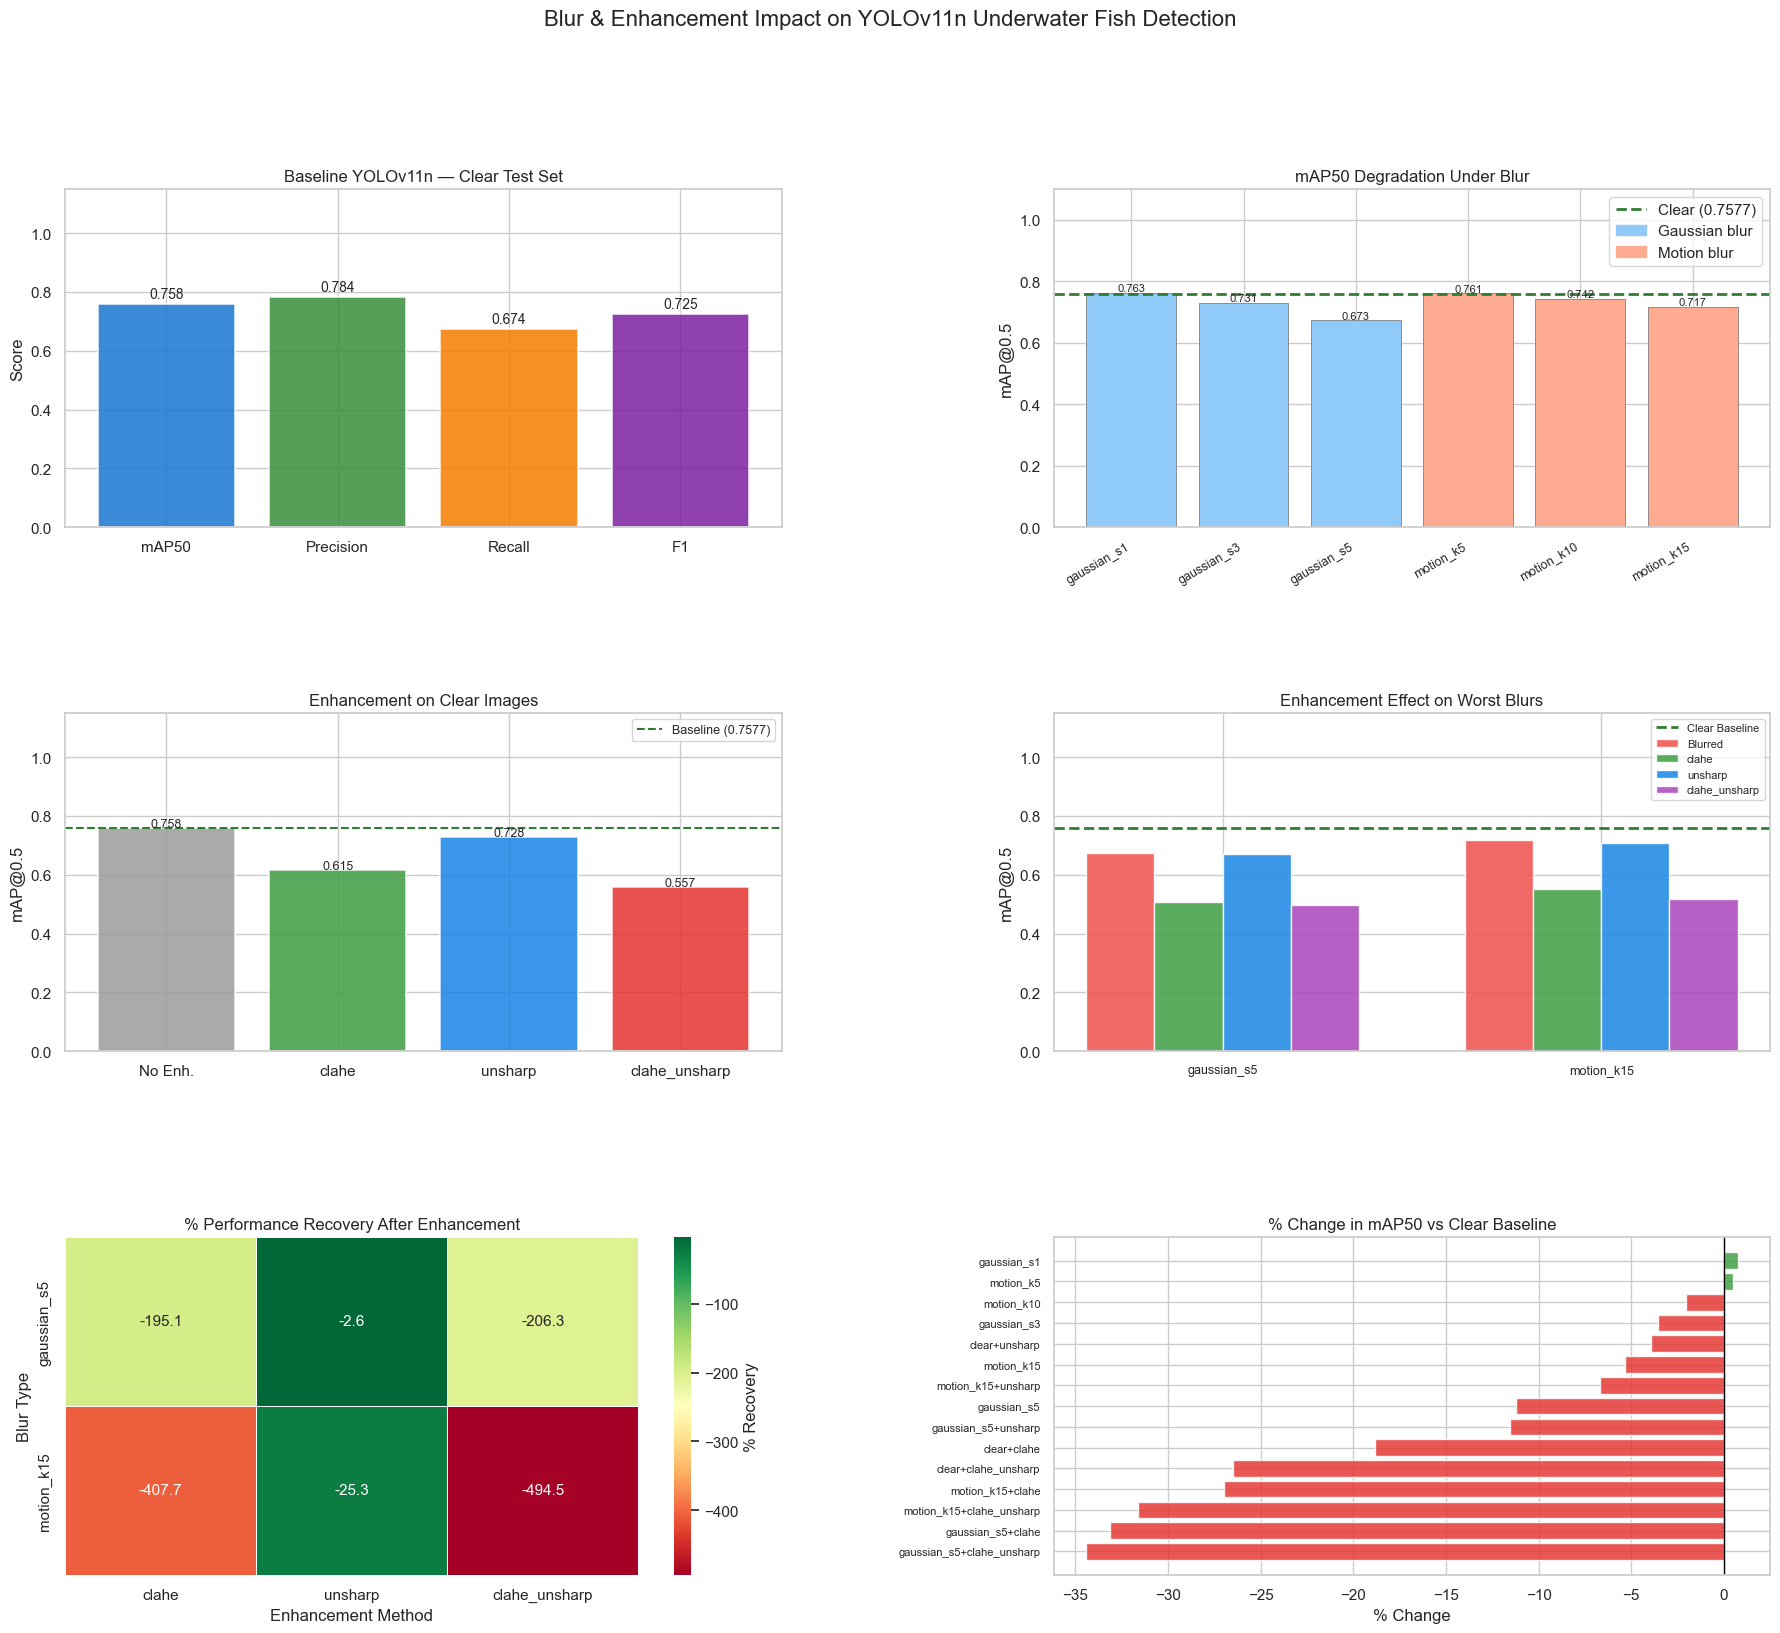

✅ Saved: analysis.png


In [ ]:
sns.set_theme(style='whitegrid')
fig = plt.figure(figsize=(22, 18))
fig.suptitle(
    'Blur & Enhancement Impact on YOLOv11n Underwater Fish Detection',
    fontsize=16, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 2, hspace=0.55, wspace=0.38)

# ── 1. Baseline metric bar chart ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
metrics_k = ['mAP50', 'Precision', 'Recall', 'F1']
vals = [baseline_metrics[k] for k in metrics_k]
colors1 = ['#1976D2', '#388E3C', '#F57C00', '#7B1FA2']
bars = ax1.bar(metrics_k, vals, color=colors1, alpha=0.85, edgecolor='white', linewidth=1.2)
for b, v in zip(bars, vals):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.01, f'{v:.3f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1.set_ylim(0, 1.15)
ax1.set_title(f'Baseline YOLOv11n — Clear Test Set', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score')

# ── 2. mAP50 drop under blur ───────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
blur_keys = [k for k in blur_results if k != 'clear']
blur_maps = [blur_results[k]['mAP50'] for k in blur_keys]
bar_colors = ['#90CAF9'] * 3 + ['#FFAB91'] * 3
bars2 = ax2.bar(blur_keys, blur_maps, color=bar_colors, edgecolor='grey', linewidth=0.6)
ax2.axhline(CLEAR_MAP, color='#2E7D32', ls='--', lw=2, label=f'Clear ({CLEAR_MAP:.4f})')
for b in bars2:
    ax2.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', fontsize=8)
ax2.set_xticklabels(blur_keys, rotation=30, ha='right', fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.set_title('mAP50 Degradation Under Blur', fontsize=12, fontweight='bold')
ax2.set_ylabel('mAP@0.5')
ax2.legend()
from matplotlib.patches import Patch
ax2.legend(handles=[
    ax2.get_lines()[0],
    Patch(color='#90CAF9', label='Gaussian blur'),
    Patch(color='#FFAB91', label='Motion blur')
])

# ── 3. Enhancement on clear images ────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 0])
enh_names   = ['clear'] + [f'clear+{e}' for e in ENHANCE_CONFIGS]
enh_labels  = ['No Enh.'] + list(ENHANCE_CONFIGS.keys())
enh_maps    = [blur_results['clear']['mAP50']] + [enh_results[k]['mAP50'] for k in enh_names[1:]]
enh_colors  = ['#9E9E9E', '#43A047', '#1E88E5', '#E53935']
bars3 = ax3.bar(enh_labels, enh_maps, color=enh_colors, alpha=0.88, edgecolor='white', linewidth=1.1)
ax3.axhline(CLEAR_MAP, color='#2E7D32', ls='--', lw=1.5, label=f'Baseline ({CLEAR_MAP:.4f})')
for b in bars3:
    ax3.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
             f'{b.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')
ax3.set_ylim(0, 1.15)
ax3.set_title('Enhancement on Clear Images', fontsize=12, fontweight='bold')
ax3.set_ylabel('mAP@0.5')
ax3.legend(fontsize=9)

# ── 4. Enhancement recovery on worst blurs ─────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 1])
groups = WORST_BLURS
x4 = np.arange(len(groups))
w4 = 0.18
slot_labels = ['Blurred'] + list(ENHANCE_CONFIGS.keys())
slot_colors = ['#EF5350', '#43A047', '#1E88E5', '#AB47BC']
for i, (lbl, col) in enumerate(zip(slot_labels, slot_colors)):
    if lbl == 'Blurred':
        vals4 = [blur_results[g]['mAP50'] for g in groups]
    else:
        vals4 = [enh_results.get(f'{g}+{lbl}', {}).get('mAP50', 0) for g in groups]
    offset = (i - len(slot_labels)/2 + 0.5) * w4
    ax4.bar(x4 + offset, vals4, w4, label=lbl, color=col, alpha=0.87)
ax4.axhline(CLEAR_MAP, color='#2E7D32', ls='--', lw=2, label='Clear Baseline')
ax4.set_xticks(x4)
ax4.set_xticklabels(groups, fontsize=9)
ax4.set_ylim(0, 1.15)
ax4.set_title('Enhancement Effect on Worst Blurs', fontsize=12, fontweight='bold')
ax4.set_ylabel('mAP@0.5')
ax4.legend(fontsize=8)

# ── 5. Recovery Heatmap ────────────────────────────────────────────────────────
ax5 = fig.add_subplot(gs[2, 0])
enh_keys = list(ENHANCE_CONFIGS.keys())
heat_data = pd.DataFrame(index=WORST_BLURS, columns=enh_keys, dtype=float)
for b in WORST_BLURS:
    for e in enh_keys:
        tag = f'{b}+{e}'
        row = df_all[df_all['Condition'] == tag]
        if not row.empty:
            heat_data.loc[b, e] = float(row['Recovery(%)'].values[0])
sns.heatmap(
    heat_data.astype(float), annot=True, fmt='.1f', cmap='RdYlGn',
    ax=ax5, linewidths=0.5, cbar_kws={'label': '% Recovery'},
    annot_kws={'size': 11, 'weight': 'bold'}
)
ax5.set_title('% Performance Recovery After Enhancement', fontsize=12, fontweight='bold')
ax5.set_xlabel('Enhancement Method')
ax5.set_ylabel('Blur Type')

# ── 6. vs_clear % bar chart for all conditions ────────────────────────────────
ax6 = fig.add_subplot(gs[2, 1])
df_delta = df_all[df_all['Condition'] != 'clear'].copy()
df_delta = df_delta.sort_values('vs_clear(%)', ascending=True)
delta_colors = ['#E53935' if v < 0 else '#43A047' for v in df_delta['vs_clear(%)']]
ax6.barh(df_delta['Condition'], df_delta['vs_clear(%)'], color=delta_colors, alpha=0.85)
ax6.axvline(0, color='black', linewidth=1)
ax6.set_title('% Change in mAP50 vs Clear Baseline', fontsize=12, fontweight='bold')
ax6.set_xlabel('% Change')
ax6.tick_params(axis='y', labelsize=8)

plt.savefig(RESULTS_DIR / 'analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: analysis.png')

## Step 11: Visual Sample — Clear → Blur → Enhancement

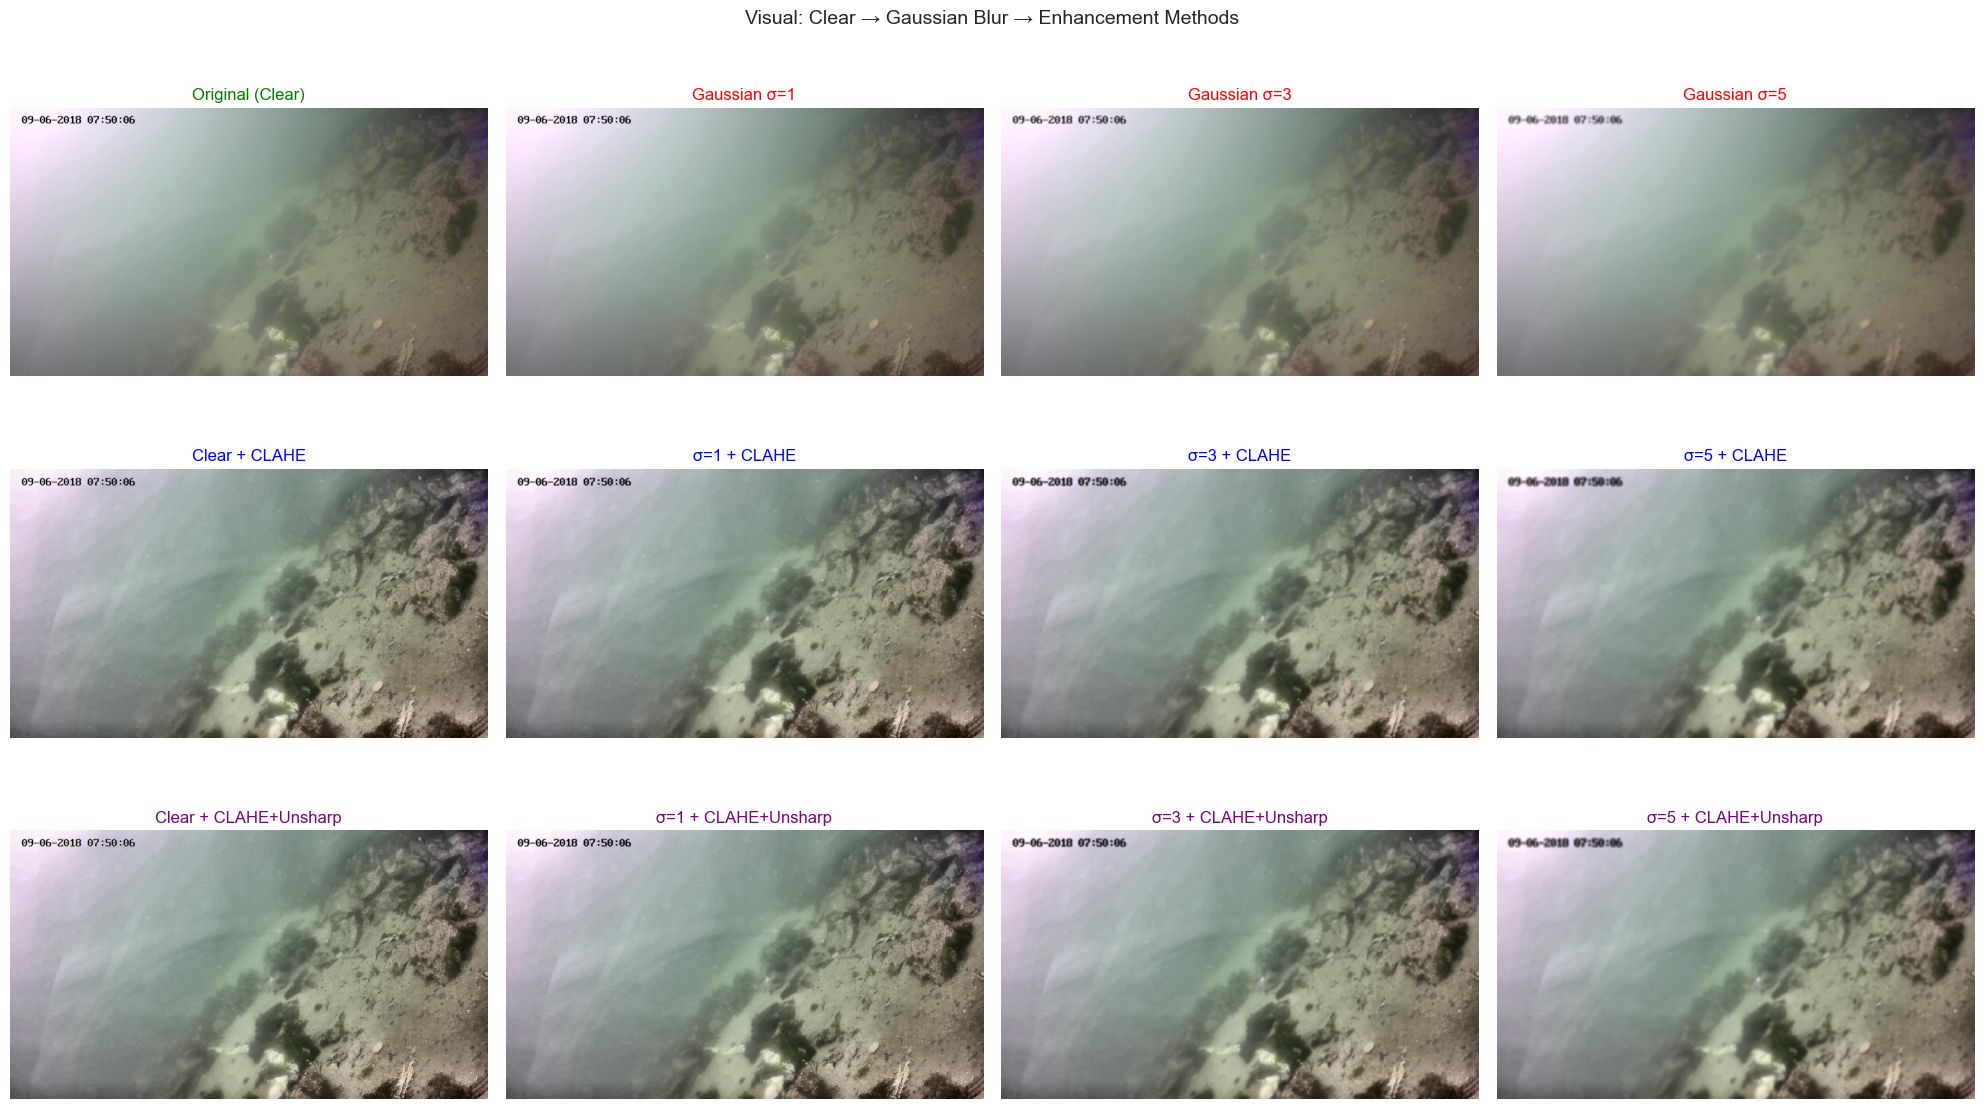

✅ Saved: visual_samples.png


In [ ]:
all_imgs = [p for p in TEST_IMG_DIR.iterdir()
            if p.suffix.lower() in ['.jpg', '.jpeg', '.png']]
sample = random.choice(all_imgs)
orig   = cv2.imread(str(sample))

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
fig.suptitle(
    'Visual: Clear → Gaussian Blur → Enhancement Methods',
    fontsize=14, fontweight='bold'
)

sigmas = [1, 3, 5]

# Row 0: Original + Blurred
axes[0][0].imshow(cv2.cvtColor(orig, cv2.COLOR_BGR2RGB))
axes[0][0].set_title('Original (Clear)', fontweight='bold', color='green')
for i, s in enumerate(sigmas):
    blurred = gaussian_blur(orig, s)
    axes[0][i+1].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
    axes[0][i+1].set_title(f'Gaussian σ={s}', color='red')

# Row 1: CLAHE
axes[1][0].imshow(cv2.cvtColor(apply_clahe(orig), cv2.COLOR_BGR2RGB))
axes[1][0].set_title('Clear + CLAHE', fontweight='bold', color='blue')
for i, s in enumerate(sigmas):
    enhanced = apply_clahe(gaussian_blur(orig, s))
    axes[1][i+1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
    axes[1][i+1].set_title(f'σ={s} + CLAHE', color='blue')

# Row 2: CLAHE + Unsharp (Combined — best)
axes[2][0].imshow(cv2.cvtColor(apply_clahe_unsharp(orig), cv2.COLOR_BGR2RGB))
axes[2][0].set_title('Clear + CLAHE+Unsharp', fontweight='bold', color='purple')
for i, s in enumerate(sigmas):
    enhanced = apply_clahe_unsharp(gaussian_blur(orig, s))
    axes[2][i+1].imshow(cv2.cvtColor(enhanced, cv2.COLOR_BGR2RGB))
    axes[2][i+1].set_title(f'σ={s} + CLAHE+Unsharp', color='purple')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'visual_samples.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: visual_samples.png')

## Step 12: Final Summary

In [ ]:
print('=' * 70)
print('FINAL SUMMARY — YOLOv11n Underwater Fish Detection')
print('=' * 70)

print(f'\nModel               : YOLOv11n')
print(f'Clear Baseline mAP50: {CLEAR_MAP}')
print(f'\nBaseline Metrics:')
print(pd.DataFrame([baseline_metrics]).to_string(index=False))

worst = min(
    (k for k in blur_results if k != 'clear'),
    key=lambda k: blur_results[k]['mAP50']
)
print(f'\nWorst Blur Condition: {worst}')
print(f'  → mAP50 = {blur_results[worst]["mAP50"]} (drop = {pct(blur_results[worst]["mAP50"], CLEAR_MAP):.2f}%)')

if enh_results:
    best_enh = max(enh_results, key=lambda k: enh_results[k]['mAP50'])
    print(f'\nBest Enhancement Overall : {best_enh}')
    print(f'  → mAP50 = {enh_results[best_enh]["mAP50"]} ({pct(enh_results[best_enh]["mAP50"], CLEAR_MAP):+.2f}% vs clear)')

    # Show all enhancement results vs clear
    print('\nEnhancement Results vs Clear Baseline:')
    for tag, m in sorted(enh_results.items(), key=lambda x: -x[1]['mAP50']):
        delta = pct(m['mAP50'], CLEAR_MAP)
        sign  = '+' if delta >= 0 else ''
        print(f'  {tag:<35} mAP50={m["mAP50"]:.4f}  ({sign}{delta:.2f}%)')

print('\nSaved files:')
for f in sorted(RESULTS_DIR.rglob('*.csv')) + sorted(RESULTS_DIR.rglob('*.png')):
    print(f'  {f}')

print('\n✅ PIPELINE COMPLETE')

FINAL SUMMARY — YOLOv11n Underwater Fish Detection

Model               : YOLOv11n
Clear Baseline mAP50: 0.7577

Baseline Metrics:
 mAP50  Precision  Recall     F1  FPS
0.7577     0.7839  0.6742 0.7249  8.2

Worst Blur Condition: gaussian_s5
  → mAP50 = 0.6726 (drop = -11.23%)

Best Enhancement Overall : clear+unsharp
  → mAP50 = 0.7281 (-3.91% vs clear)

Enhancement Results vs Clear Baseline:
  clear+unsharp                       mAP50=0.7281  (-3.91%)
  motion_k15+unsharp                  mAP50=0.7072  (-6.66%)
  gaussian_s5+unsharp                 mAP50=0.6704  (-11.52%)
  clear+clahe                         mAP50=0.6149  (-18.85%)
  clear+clahe_unsharp                 mAP50=0.5568  (-26.51%)
  motion_k15+clahe                    mAP50=0.5531  (-27.00%)
  motion_k15+clahe_unsharp            mAP50=0.5181  (-31.62%)
  gaussian_s5+clahe                   mAP50=0.5066  (-33.14%)
  gaussian_s5+clahe_unsharp           mAP50=0.4970  (-34.41%)

Saved files:
  /kaggle/working/results/compari